In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import holidays
from utils.sku_freq_check import classify_forecast_tier

In [3]:
df = pd.read_csv('../data/raw/cleaned_transactions.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


In [4]:
df = df[df["Quantity"] > 0]

In [5]:
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

# create tiers
tiers = classify_forecast_tier(
    df,
    sku_col="StockCode",
    date_col="InvoiceDate",
    invoice_col="InvoiceNo",
    weekly_min_active_months_frac=0.8,   # active in ~80%+ of the observed span
    monthly_min_active_months=3,         # at least a handful of active months
)

print(tiers["forecast_tier"].value_counts())

forecast_tier
weekly     2358
monthly    1375
manual      518
Name: count, dtype: int64


In [6]:
merged_df = df.merge(tiers[["StockCode", "forecast_tier"]], on="StockCode")
print(merged_df.groupby("forecast_tier")["Quantity"].sum() / merged_df["Quantity"].sum())

forecast_tier
manual     0.007972
monthly    0.119996
weekly     0.872032
Name: Quantity, dtype: float64


In [7]:
weekly_skus = tiers.loc[tiers["forecast_tier"] == "weekly", "StockCode"]

new_df = df[df["StockCode"].isin(weekly_skus)]

new_df["Quantity"].describe()

count    438031.000000
mean         11.572418
std          77.138227
min           1.000000
25%           1.000000
50%           4.000000
75%          12.000000
max       12960.000000
Name: Quantity, dtype: float64

In [8]:
new_df["Quantity"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]) 

0.50      4.0
0.75     12.0
0.90     24.0
0.95     32.0
0.99    120.0
Name: Quantity, dtype: float64

In [9]:
# Sanity check: exactly one row, one tier, per SKU
dupe_check = tiers.groupby("StockCode")["forecast_tier"].nunique()
assert (dupe_check == 1).all(), "Some SKUs have more than one tier assignment"

# Confirm every SKU appears in exactly one tier and counts sum correctly
print(tiers["forecast_tier"].value_counts())
print(f"Total SKUs across tiers: {tiers['forecast_tier'].value_counts().sum()}")
print(f"Total distinct SKUs: {tiers['StockCode'].nunique()}")  # should match

forecast_tier
weekly     2358
monthly    1375
manual      518
Name: count, dtype: int64
Total SKUs across tiers: 4251
Total distinct SKUs: 4251


# Filter 99th Percentile

In [10]:
df = new_df[new_df['Quantity'] < 120]
print(df.shape[0])
print(df["Quantity"].describe())

433364
count    433364.000000
mean          8.062093
std          12.665568
min           1.000000
25%           1.000000
50%           3.000000
75%          10.000000
max         119.000000
Name: Quantity, dtype: float64


In [11]:
# Convert InvoiceDate to datetime and set it as index for time-series modeling
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
print(df['InvoiceDate'].max())
print(df['InvoiceDate'].min()) 

2010-12-09 00:00:00
2009-12-01 00:00:00


# Feature Engineering

### Aggregate Data to Daily Demand

In [13]:
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

def aggregate_daily_demand(df):

    daily_demand = (
        df.groupby(
            ["InvoiceDate", "StockCode"],
            as_index=False
        )
        .agg(
            Quantity=("Quantity", "sum"),
            Price=("Price", "mean")
        )
    )

    return daily_demand

daily_demand_df = aggregate_daily_demand(df)

In [14]:
daily_demand_df.head()

,InvoiceDate,StockCode,Quantity,Price
0,2009-12-01,10002,12,0.850
1,2009-12-01,10120,60,0.210
2,2009-12-01,10123C,3,1.300
3,2009-12-01,10125,5,1.275
4,2009-12-01,10133,6,0.850


In [15]:
daily_demand_df.shape

(230347, 4)

In [16]:
# timebased train-valid split
cutoff_date = '2010-10-01'

def train_valid_split(
    df,
    date_col,
    split_date
):

    train_df = df[
        df[date_col] < split_date
    ]

    valid_df = df[
        df[date_col] >= split_date
    ]

    return train_df, valid_df

# split the features
train_df, valid_df = train_valid_split(
    daily_demand_df,
    date_col='InvoiceDate',
    split_date=cutoff_date
)

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")

Train shape: (176110, 4)
Valid shape: (54237, 4)


I will use the functions I have already written in features subfolder

In [17]:
from features.calendars import create_calendar_features
from features.easter_christmas import create_christmas_features
from features.holidays import create_holiday_features
from features.lag_features import create_lag_features
from features.momentum import create_momentum_features
from features.rolling import create_rolling_features
from features.sku import create_sku_features
from features.create_target import create_target
from features.product_lifecycle import create_product_lifecycle_features
from features.feature_pipeline import build_demand_features

In [18]:
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml"])

0

In [19]:
import pydantic
from config.feature_config import (DATE_COL, 
                                   TARGET_COL, 
                                   PRICE_COL, 
                                   PRODUCT_COL,
                                   DROP_COLS
)

In [20]:
print(DATE_COL)
print(PRICE_COL)

InvoiceDate
Price


In [21]:
# build features
train_features = build_demand_features(train_df)

In [22]:
train_features.columns

Index(['InvoiceDate', 'StockCode', 'Quantity', 'Price', 'price_ratio',
       'day_of_week', 'day_of_month', 'week_of_year', 'month', 'quarter',
       'is_weekend', 'days_to_christmas', 'christmas_window',
       'christmas_countdown', 'days_to_easter', 'easter_window', 'is_holiday',
       'holiday_name', 'days_to_next_holiday', 'days_since_previous_holiday',
       'first_sale_date', 'days_since_first_sale', 'lag_1', 'lag_7', 'lag_14',
       'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14',
       'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'momentum_7_28',
       'momentum_14_28', 'sku_mean_qty', 'sku_median_qty', 'sku_std_qty',
       'sku_cv', 'sku_avg_price', 'target'],
      dtype='str')

In [23]:
# Reuse feature builder on test no re-fit.
test_df = build_demand_features(valid_df)

In [24]:
train_features.head()

,InvoiceDate,StockCode,Quantity,Price,price_ratio,day_of_week,day_of_month,week_of_year,month,quarter,...,rolling_mean_28,rolling_std_28,momentum_7_28,momentum_14_28,sku_mean_qty,sku_median_qty,sku_std_qty,sku_cv,sku_avg_price,target
0,2009-12-01,10002,12,0.85,0.883752,1,1,49,12,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.564949
2060,2009-12-03,10002,6,0.85,0.883752,3,3,49,12,4,...,NaN,NaN,NaN,NaN,12.000000,12.0,NaN,NaN,0.85,1.945910
3086,2009-12-04,10002,73,0.85,0.883752,4,4,49,12,4,...,NaN,NaN,NaN,NaN,9.000000,9.0,4.242641,0.471404,0.85,4.304065
4295,2009-12-06,10002,49,0.85,0.883752,6,6,49,12,4,...,NaN,NaN,NaN,NaN,30.333333,12.0,37.072002,1.222154,0.85,3.912023
5034,2009-12-07,10002,2,0.85,0.883752,0,7,50,12,4,...,NaN,NaN,NaN,NaN,35.000000,30.5,31.675437,0.905012,0.85,1.098612


In [25]:
train_features.shape

(176110, 40)

In [26]:
train_features['StockCode'].nunique()

2358

In [27]:
train_features['InvoiceDate'].max()

Timestamp('2010-09-30 00:00:00')

## Build and Train LIGHTGBM Model

In [28]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error, 
                             mean_absolute_percentage_error)

# model parameters
params = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

In [29]:
X_train = train_features.drop(columns = DROP_COLS, errors = "ignore")
y_train = train_features[TARGET_COL]

X_test = test_df.drop(columns =DROP_COLS, errors = "ignore")
y_test = test_df[TARGET_COL]   

In [30]:
X_train.columns

Index(['Price', 'price_ratio', 'day_of_week', 'day_of_month', 'week_of_year',
       'month', 'quarter', 'is_weekend', 'days_to_christmas',
       'christmas_window', 'christmas_countdown', 'days_to_easter',
       'easter_window', 'is_holiday', 'holiday_name', 'days_to_next_holiday',
       'days_since_previous_holiday', 'days_since_first_sale', 'lag_1',
       'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28',
       'rolling_std_28', 'momentum_7_28', 'momentum_14_28', 'sku_mean_qty',
       'sku_median_qty', 'sku_std_qty', 'sku_cv', 'sku_avg_price'],
      dtype='str')

In [31]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [32]:
#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6251
[LightGBM] [Info] Number of data points in the train set: 176110, number of used features: 33
[LightGBM] [Info] Start training from score 14.760400
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[531]	valid_0's rmse: 18.925


In [33]:
# make predictions
predictions = model.predict(X_test)

### Evaluation

In [34]:
from models.evaluate import evaluate, wmape_sklearn, weighted_mape

evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 11.247420165716699,
 'RMSE': 18.924979711107408,
 'wmape_sklearn': np.float64(0.6820760689157545),
 'WMAPE': np.float64(0.6820760689157545)}

In [35]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE: 17.17%


In [36]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias: 13.47%
Alt result: 13.47%


### Feature Importance

Plot the feature importance to see what drove these predictions

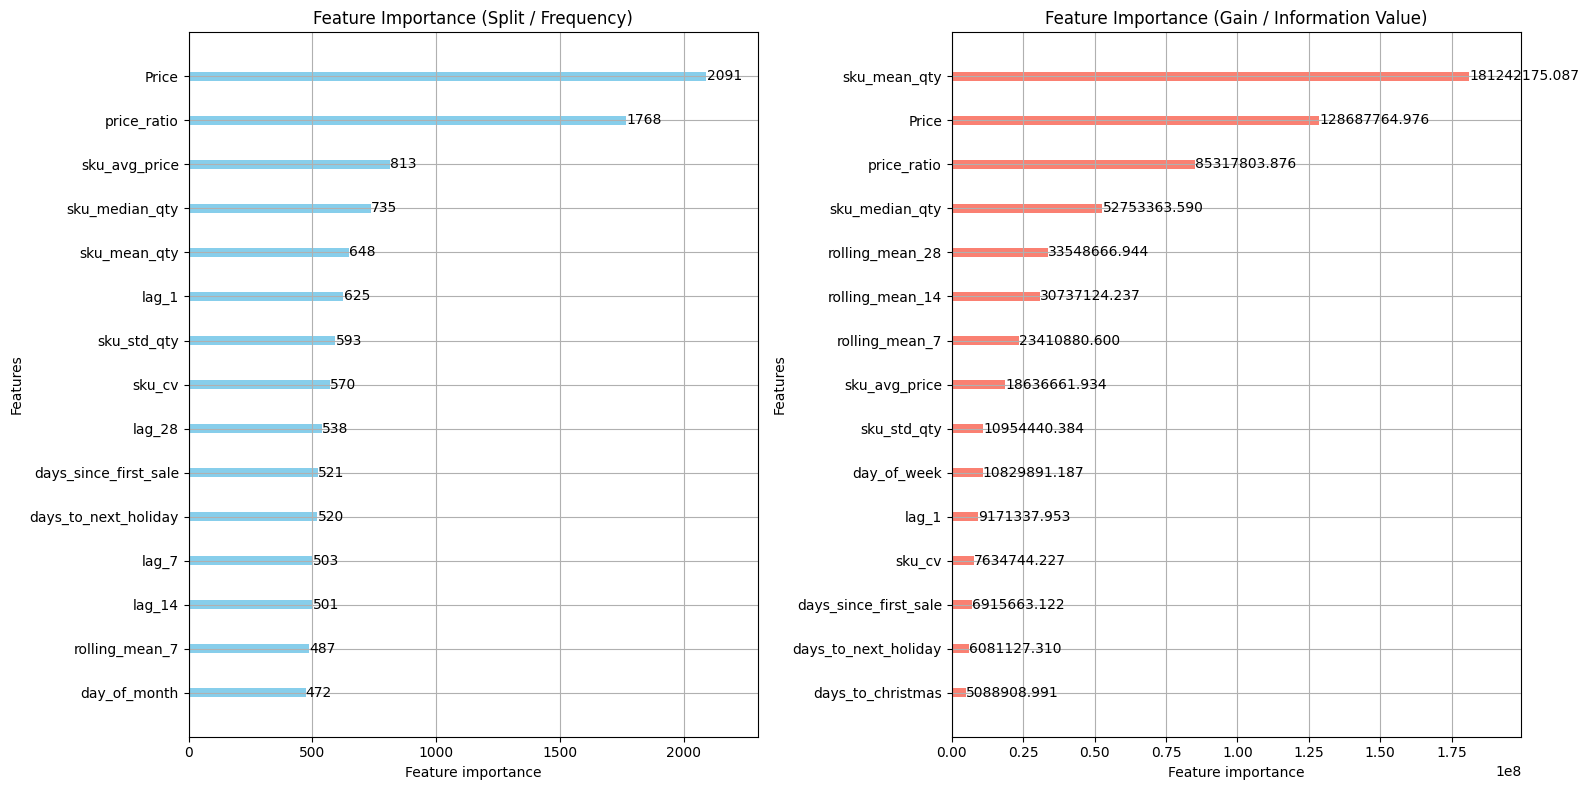

In [37]:
import matplotlib.pyplot as plt

# Configure a side-by-side plotting area
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


# Loss Function Adjustment to tweedie

By default, LightGBM optimizes for RMSE (objective: 'regression'). I want the model to focus less on penalizing these extreme outliers and instead optimize for overall percentage accuracy. Therefore, I change LightGBM objective parameter

In [38]:
# Update parameters to fix underfitting
params = {
    "objective": "tweedie",  
    "metric": "rmse",
    "tweedie_variance_power": 1.5,  # 1.5 is standard for retail sales
    "learning_rate": 0.01,
    "num_leaves": 63,
}

# Run training with more boosting rounds
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

# make predictions
tweedie_predictions = model.predict(X_test)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = tweedie_predictions)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6251
[LightGBM] [Info] Number of data points in the train set: 176110, number of used features: 33
[LightGBM] [Info] Start training from score 2.691948
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1834]	valid_0's rmse: 18.7274


Eval metrics


{'MAE': 10.749216655831416,
 'RMSE': 18.72740093582523,
 'wmape_sklearn': np.float64(0.6518635680457),
 'WMAPE': np.float64(0.6518635680457)}

### Plot feature importance for tweedie

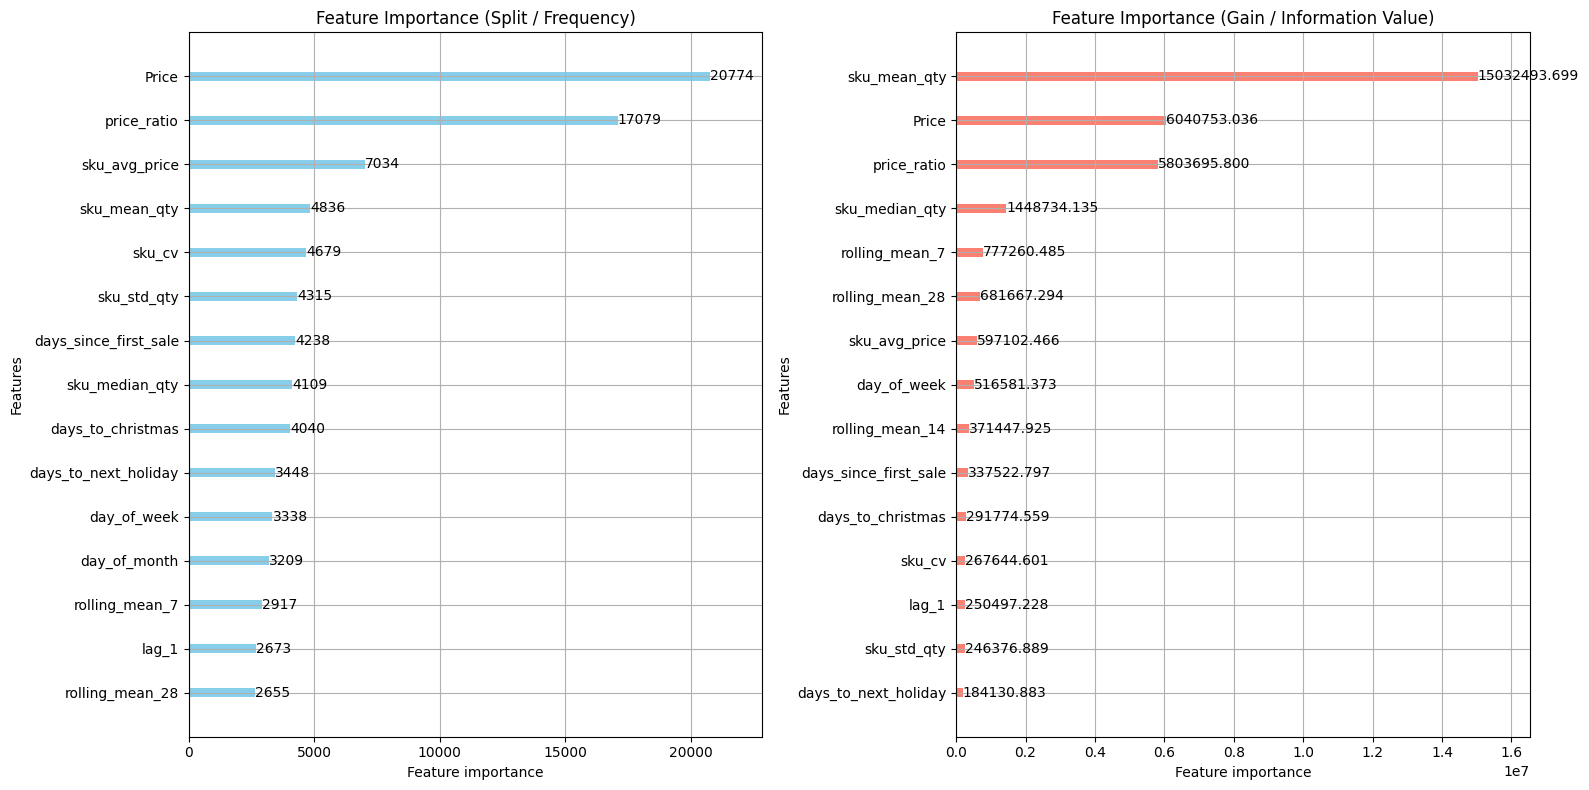

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


In [40]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = tweedie_predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

# verify the alignment side-by-side
print(test_df[["InvoiceDate", "StockCode", "actual_demand", "predicted_demand"]].head())

       InvoiceDate StockCode  actual_demand  predicted_demand
176110  2010-10-01     11001             16         15.583093
176111  2010-10-01     16048             24         15.905777
176112  2010-10-01    16161P             25         22.524137
176113  2010-10-01     16236              6         23.970882
176114  2010-10-01     16237              5         20.120207


In [41]:
#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for tweedie: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE for tweedie: 14.17%


### Model bias

In [42]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias for tweedie: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias for tweedie: 9.31%
Alt result: 9.31%


- Aggregating data from daily to weekly dropped the **WMAPE from 65.1% down to 14.2%**. 
- For an online retailer, a 14.2% weekly WMAPE is a solid, operationally viable baseline. 
- Model's bias, however, is 9.3%, meaning it is over-predicting sales by 9 percent which is above the industry benchmark of plus/minus five.

# Try Objective Quantile

In [43]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)


# Define parameters for Quantile Regression
params = {
    'objective': 'quantile',
    'alpha': 0.60,              # Predicts the 58th percentile (adjust per segment)
    'metric': 'quantile',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'verbosity': -1,
    'seed': 42
}

# Train with quantile regression
q_model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[train_data, test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50), 
                  lgb.log_evaluation(100)]
                )
# make predictions
y_pred = q_model.predict(X_test)

#evaluate them
evaluate(y_true = y_test, y_pred = y_pred)

Training until validation scores don't improve for 50 rounds
[100]	training's quantile: 4.85151	valid_1's quantile: 5.49754
[200]	training's quantile: 4.65787	valid_1's quantile: 5.37303
[300]	training's quantile: 4.54062	valid_1's quantile: 5.28435
[400]	training's quantile: 4.45678	valid_1's quantile: 5.24543
[500]	training's quantile: 4.38974	valid_1's quantile: 5.22695
[600]	training's quantile: 4.36333	valid_1's quantile: 5.21736
[700]	training's quantile: 4.34493	valid_1's quantile: 5.21316
Early stopping, best iteration is:
[683]	training's quantile: 4.34616	valid_1's quantile: 5.21148


{'MAE': 10.364795552401517,
 'RMSE': 19.040993651879877,
 'wmape_sklearn': np.float64(0.6285511611850628),
 'WMAPE': np.float64(0.6285511611850628)}

In [44]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = y_pred

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE with quantiles: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE with quantiles: 11.29%


In [45]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias using quantiles: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias using quantiles: -1.76%
Alt result: -1.76%


- Using quantile ojbective gives the best weekly WMAPE of **11.3%** and a bias of **-1.8%**, both operationally viable metrics. 
- It shifts the model's performance rating from poor to good.

### Why the Error Dropped So Drastically

**Day-of-Week Noise Self-Corrects:** 

Daily e-commerce sales fluctuate heavily (e.g., lower sales on Fridays, spikes on Mondays). When you pool these days into a 7-day bucket, the random daily timing variations cancel each other out. 

**Intraday Shipping and Order Latency Erasure:** 

Web traffic and processing delays frequently shift a Monday night order to a Tuesday morning fulfillment. Weekly aggregation completely erases this timing noise.

### Recommendations

**Supply Chain & Inventory (Use Weekly):** A 11.3% error rate is accurate enough to drive bulk inventory purchasing, warehouse space allocation, and vendor purchase orders. 

**Labor & Daily Ops (Do Not Use Daily):** The daily metrics proved the model is too unstable for scheduling day-to-day warehouse picking shifts or managing real-time server scaling. 

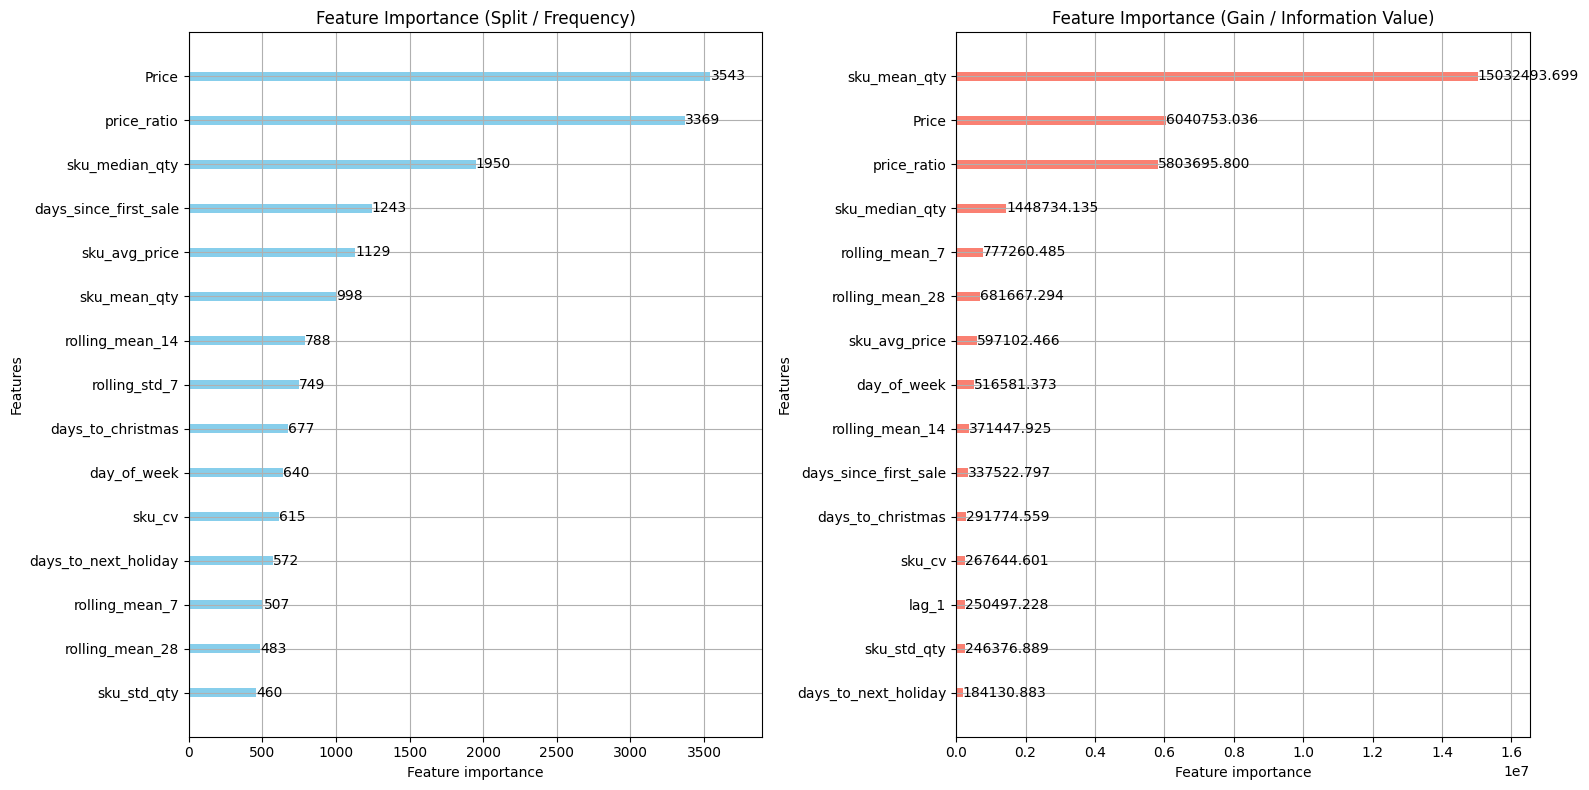

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    q_model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()

### Top 10 features for split

1. Price (3,543)
2. Price ratio (3,369)
3. SKU median quantity (1,950)
4. Days since first sale (1,243)
5. SKU avg price (1,129)
6. SKU mean quantity (998)
7. Rolling mean 14 (788)
8. Rolling std 7 (749)
9. Days to christmas (677)
10. Day of week (640)

### Top 10 features for gain

1. SKU mean quantity (15,032,493)
2. Price (6,040,753)
3. Price ratio (5,803,695)
4. SKU median quantity (1,448,734)
5. Rolling mean 7 (777,260)
6. Rolling mean 28 (681,667)
7. SKU avg price (597,102)
8. Day of week (516,581)
9. Rolling mean 14 (371,447)
10. Day since first sale (337,522)

# Objective Huber Loss

In [47]:
# Update training parameters to huber loss function
params = {
    'objective': "huber",
    'metric': "rmse",
    #'num_leaves': 31,
    #'boosting_type': "gbdt",
    'learning_rate': 0.045,
     'n_estimators': 500,
     #'colsample_bytree': 0.8,
     #'subsample': 0.8,
     'random_state': 42,
     'verbosity': 0
}

#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])

# make predictions
huber_pred = model.predict(X_test)
evaluate(y_true = y_test, y_pred = huber_pred)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 23.8285


{'MAE': 11.077773188042581,
 'RMSE': 23.82847987734197,
 'wmape_sklearn': np.float64(0.6717881858340765),
 'WMAPE': np.float64(0.6717881858340764)}

In [48]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = huber_pred

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for huber loss: {weekly_wmape:.2%}")

## bias sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100

print(f"Model bias for huber loss: {bias_fo:.2f}%")


Weekly Aggregated WMAPE for huber loss: 37.39%
Model bias for huber loss: -37.39%


# Log Transform Target

In [49]:
# log transform target
y_train_log = np.log1p(train_df[TARGET_COL])
y_test_log = valid_df[TARGET_COL] 

# create train data with log target
# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [50]:
# Train model using y_train_log with regression
# model parameters
params1 = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

model = lgb.train(params1, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Inverse transform predictions before evaluating
log_predictions = model.predict(X_test)
final_predictions = np.expm1(log_predictions)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = final_predictions)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 29.906


Eval metrics


{'MAE': 13.86743573474741,
 'RMSE': 27.864267387716744,
 'wmape_sklearn': np.float64(0.8409613860367112),
 'WMAPE': np.float64(0.8409613860367111)}

In [51]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for log transformed target: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE for log transformed target: 17.17%


In [52]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100

print(f"Model Bias for log transformed target: {bias:.2f}%")

Model Bias for log transformed target: 13.47%


Log transforming the target gives a weekly WMAPE that is within the industry benchmark (17.8%) but is over-forecasting by a higher rate (13.5%)